Inport Relevant Libraries

In [1]:
# Parallelization
import os # Operating system interface
import tempfile
import multiprocessing as mp # Package for supporting spawning processes using APi similar to threading module
from multiprocessing import Pool # Allows pooling resources into subprocesses for making effective use of multiple cpus
from multiprocessing import cpu_count # Counts the number of cpu's in current system
import concurrent.futures
from concurrent.futures import ProcessPoolExecutor # Class for parallelization that serves an updated version of pool

# MDAnalysis
import MDAnalysis as mda # Package for general simulation analysis
from MDAnalysis.lib.distances import distance_array

# Plotting
import matplotlib.pyplot as plt # Comprehensive library for creating visualizations in Python
from matplotlib import cm, colors
import networkx as nx

# NGLView
import nglview as nv # Package for interactive visualization of proteins and trajectories

# NumPY
import numpy as np # Fundamental package for mathematical operations and numerical computations in Python

# Warnings
import warnings # Python core function for handling built-in exceptions
warnings.filterwarnings('ignore') # Ignore unnessary warnings from MDAnalysis

Class for Protein Contact Network

In [2]:
# Class for finding and storing information about the physical structure and changes in the protein
class NetworkAnalysis:
    StructureFileTypes = {'.psf','.pdb','.gro'} # Available structure file types
    TrajectoryFileTypes = {'.dcd','.xtc','.trr'} # Available trajectory file types

    # Function for initiating protein universes
    def __init__(self,Structure,Trajectory=None,Pore=None,FrameStep=100,BatchSize=5):
        if all(isinstance(Struct,str) for Struct in Structure): # If structure input is a string, assigns to structure
            Structures = Structure
        elif not isinstance(Structure,list): # Otherwise outputs an error for wrong input type
            raise TypeError("Structure must either be a string or a list of strings.")
        if Trajectory is None: # No trajectory file required, instead makes a blank structure for universe creation
            Trajectories = None * len(Structure)
        elif  all(isinstance(Traj,str) for Traj in Trajectory): # If trajectory exists and is a string/list of strings, creates trajectory object
            Trajectories = Trajectory
        elif not isinstance(Trajectory,list): # If provided and wrong file type, outputs error
            raise TypeError("Trajectory must be a string, a list of strings, or none.")
        if len(Structures) != len(Trajectories): # If there are not the same amount of structures and trajectories, produce error
            raise ValueError("The number of structures and trajectories must be the same.")
        for Struct in Structure: # Checks for every structure if in supported structure file types
            if os.path.splitext(Struct)[1].lower() not in self.StructureFileTypes:
                raise ValueError(f"File type {os.path.splitext(Struct)[1].lower()} is unsupported for structures.")
        for Traj in Trajectory: # Checks for every trajectory if in supported file types
            if Traj is not None:
                if os.path.splitext(Traj)[1].lower() not in self.TrajectoryFileTypes:
                    raise ValueError(f"File type {os.path.splitext(Traj)[1].lower()} is unsupported for trajectories.")
        # Creates universe from structures and optionally and trajectory
        self.Universe = [mda.Universe(Struct,Traj) if Traj else mda.Universe(Struct) for Struct,Traj in zip(Structures,Trajectories)]
        self.StructureList = Structures
        self.TrajectoryList = Trajectories
        self.FrameStep = FrameStep # Saves frame step, i.e. with what frequency are frames read
        self.BatchSize = BatchSize # Batchsize for parallel processing

    # Method for creating a list of frames for study in simulation
    def FrameBatches(self, FrameList):
        for i in range(0, len(FrameList), self.BatchSize): # Selects frames with reference to batch size as well
            yield FrameList[i:i + self.BatchSize] 

    # Function to build a matrix of protein atom to protein atom distances for contact analysis
    def ProteinDistanceNetwork(self,StartFrame=0,EndFrame=None,ProteinSelection="protein"):
        ProteinDistances = [] 
        for U in self.Universe:
            if EndFrame is None:
                EndFrame = len(U.trajectory)
            FrameIndices = list(range(StartFrame, EndFrame, self.FrameStep))
            Protein = U.select_atoms(ProteinSelection)
            NumAtoms = len(Protein)
            DistanceSum = np.zeros((NumAtoms,NumAtoms),dtype=np.float32)
            for Frame in FrameIndices:
                U.trajectory[Frame] 
                AtomCoords = Protein.positions
                DistanceSum += distance_array(AtomCoords,AtomCoords)
            ProteinDistances.append(DistanceSum/len(FrameIndices))
        self.DistanceNetwork = np.array(ProteinDistances)

    # Function to build a matrix of protein atom to protein atom contacts and probabilities
    def ProteinContactNetwork(self,StartFrame=0,EndFrame=None,InterCutoff=12,ProteinSelection="protein"):
        ProteinContacts = []
        for U in self.Universe:
            if EndFrame is None:
                EndFrame = len(U.trajectory)
            FrameIndices = range(StartFrame, EndFrame, self.FrameStep)
            Protein = U.select_atoms(ProteinSelection)
            NumAtoms = len(Protein)
            ContactSum = np.zeros((NumAtoms, NumAtoms), dtype=np.float32)
            for Frame in FrameIndices:
                U.trajectory[Frame]
                AtomCoords = Protein.positions.astype(np.float32)
                Distances = distance_array(AtomCoords, AtomCoords, box=U.dimensions)
                Contacts = Distances < InterCutoff
                ContactSum += Contacts.astype(np.float32)
            ContactFreq = ContactSum / len(FrameIndices)
            ProteinContacts.append(ContactFreq.astype(np.float32))
        self.ContactFrequency = np.array(ProteinContacts, dtype=np.float32)

Protein Contact Probability Normalization Function

In [3]:
def ContactFrequencyNormalization(ProbabilityDensity, UniverseSelection, NumProtomer):
    NumProtAtom = ProbabilityDensity.shape[2]
    NumAtomProtomer = NumProtAtom // NumProtomer
    IMap = np.arange(NumProtAtom) % NumAtomProtomer
    JMap = np.arange(NumProtAtom) % NumAtomProtomer
    I, J = np.meshgrid(IMap, JMap, indexing='ij')
    ProteinDensityAve = ProbabilityDensity[UniverseSelection].mean(axis=0)
    ProtomerDensityAve = np.zeros((NumAtomProtomer, NumAtomProtomer), dtype=np.float32)
    np.add.at(ProtomerDensityAve, (I, J), ProteinDensityAve)
    ProtomerDensityAve /= NumProtomer
    ProtomerDensityAve = np.clip(ProtomerDensityAve, 0, 1.0)
    return ProtomerDensityAve

Protein-Protein Distance Matrix Calculations

In [4]:
Structures = ["/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/280K00/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/280K05/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/280K10/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/280K15/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/310K00/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/310K05/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/310K10/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/310K15/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/315K00/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/315K05/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/315K10/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/315K15/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/325K00/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/325K05/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/325K10/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/325K15/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/340K00/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/340K05/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/340K10/EquilibrationStep4.gro",
              "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/340K15/EquilibrationStep4.gro"]

Trajectories = ["/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/280K00/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/280K05/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/280K10/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/280K15/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/310K00/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/310K05/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/310K10/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/310K15/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/315K00/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/315K05/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/315K10/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/315K15/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/325K00/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/325K05/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/325K10/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/325K15/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/340K00/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/340K05/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/340K10/NPT.xtc",
                "/lustre/hdd/LAS/potoyan-lab/zach/TRPV1Simulations/CoarseCompletedV2/340K15/NPT.xtc"]

ProteinNetwork = NetworkAnalysis(Structures,Trajectories)
ProteinNetwork.ProteinContactNetwork(StartFrame=15000,ProteinSelection="protein and name BB")

Protein Distances and Contact Plotting Functions

In [5]:
def ProteinDistancePlotting(DistanceDistribution,Title):
    VMin = 0
    VMax = 15
    NumCbarTicks = 140
    CBarTickValues = np.linspace(VMin,VMax,NumCbarTicks)
    f, ProteinDistanceHeatmap = plt.subplots(figsize=(15,8))
    HeatMap = ProteinDistanceHeatmap.imshow(DistanceDistribution,cmap='viridis',aspect='equal',origin='upper',vmin=VMin,vmax=VMax)
    CBar = f.colorbar(HeatMap,ax=ProteinDistanceHeatmap)
    CBar.set_label('Contact Probability',fontsize=14)
    CBar.ax.tick_params(labelsize=12)
    CBar.set_ticks(CBarTickValues)
    ProteinDistanceHeatmap.set_title(Title,fontsize=16)
    ProteinDistanceHeatmap.set_xlabel('Residue Index',fontsize=14)
    ProteinDistanceHeatmap.set_ylabel('Residue Index',fontsize=14)
    ProteinDistanceHeatmap.tick_params(axis='both', which='major', labelsize=12)
    ProteinDistanceHeatmap.tick_params(axis='both', which='minor', labelsize=12)
    ProteinDistanceHeatmap.set_xticks([0,50,100,150,200,250,300,350,400,450,500,531])
    ProteinDistanceHeatmap.set_yticks([0,50,100,150,200,250,300,350,400,450,500,531])
    return

def ProteinContactFrequencyPlotting(ProbabilityDensity,Title):
    VMin = 0
    VMax = 1
    NumCbarTicks = 11
    CBarTickValues = np.linspace(VMin,VMax,NumCbarTicks)
    f, ProtContactFrequency = plt.subplots(figsize=(15,8))
    HeatMap = ProtContactFrequency.imshow(ProbabilityDensity,cmap='plasma',aspect='equal',origin='upper',vmin=VMin,vmax=VMax)
    CBar = f.colorbar(HeatMap,ax=ProtContactFrequency)
    CBar.set_label('Contact Probability',fontsize=14)
    CBar.ax.tick_params(labelsize=12)
    CBar.set_ticks(CBarTickValues)
    ProtContactFrequency.set_title(Title,fontsize=16)
    ProtContactFrequency.set_xlabel('Residue Index',fontsize=14)
    ProtContactFrequency.set_ylabel('Residue Index',fontsize=14)
    ProtContactFrequency.tick_params(axis='both', which='major', labelsize=12)
    ProtContactFrequency.tick_params(axis='both', which='minor', labelsize=12)
    ProtContactFrequency.set_xticks([0,50,100,150,200,250,300,350,400,450,500,531])
    ProtContactFrequency.set_yticks([0,50,100,150,200,250,300,350,400,450,500,531])
    return

def NetworkxInteractionPlottingMultiple(ProbabilityDensities,Indices,Titles,Labels=None,MinCutoff=0.1,MaxCutoff=1.0,MinDist=0.5):
    if len(ProbabilityDensities) != len(Titles):
        raise ValueError("Number of probability densities and titles must have the same length.")
    ReducedDensity = ProbabilityDensities[0][np.ix_(Indices,Indices)]
    if Labels is None:
        Labels = [str(i + 1) for i in Indices]
    NumLabels = len(Labels)
    Graph = nx.Graph()
    Graph.add_nodes_from(Labels)
    for i in range(NumLabels):
        for j in range(i + 1, NumLabels):
            Weight = ReducedDensity[i, j]
            if (Weight >= MinCutoff) and (Weight <= MaxCutoff):
                Graph.add_edge(Labels[i], Labels[j], weight=Weight)
    Positions = nx.kamada_kawai_layout(Graph)
    PositionsArray = np.array([Positions[Label] for Label in Labels])
    for Step in range(100):
        Moved = False
        for i in range(NumLabels):
            for j in range(i + 1, NumLabels):
                Delta = PositionsArray[i] - PositionsArray[j]
                Distance = np.linalg.norm(Delta)
                if Distance < MinDist:
                    if Distance == 0:
                        Delta = np.random.rand(2) - 0.5
                        Distance = np.linalg.norm(Delta)
                    Shift = 0.5 * (MinDist - Distance) * (Delta / Distance)
                    PositionsArray[i] += Shift
                    PositionsArray[j] -= Shift
                    Moved = True
        if not Moved:
            break
    Positions = {Label: Position for Label, Position in zip(Labels, PositionsArray)}
    for Matrix,Title in zip(ProbabilityDensities, Titles):
        ReducedDensity = Matrix[np.ix_(Indices, Indices)]
        Graph = nx.Graph()
        Graph.add_nodes_from(Labels)
        for i in range(NumLabels):
            for j in range(i + 1, NumLabels):
                Weight = ReducedDensity[i, j]
                if (Weight >= MinCutoff) and (Weight <= MaxCutoff):
                    Graph.add_edge(Labels[i], Labels[j], weight=Weight)
        Weights = [d["weight"] for _, _, d in Graph.edges(data=True)]
        NormColors = colors.Normalize(vmin=0, vmax=1)
        ColorMap = cm.plasma
        EdgeColor = [ColorMap(NormColors(w)) for w in Weights]
        EdgeWidth = [8 * (w ** 1.5) for w in Weights]
        fig, InteractionNetwork = plt.subplots(figsize=(15, 8))
        nx.draw_networkx_nodes(Graph,Positions,node_color='skyblue',node_size=1000,edgecolors='black',ax=InteractionNetwork)
        nx.draw_networkx_labels(Graph,Positions,font_size=12,ax=InteractionNetwork)
        nx.draw_networkx_edges(Graph,Positions,width=EdgeWidth,edge_color=EdgeColor,ax=InteractionNetwork)
        if len(Weights) > 0:
            Scalar = cm.ScalarMappable(cmap=ColorMap, norm=NormColors)
            Scalar.set_array([])
            CBar = fig.colorbar(Scalar,ax=InteractionNetwork)
            CBar.set_label("Contact Probability", fontsize=14)
        InteractionNetwork.set_title(Title, fontsize=16)
        InteractionNetwork.axis("off")
        plt.tight_layout()
        plt.show()

Protein Contact Probability Heat Map Plotting for Temperatures

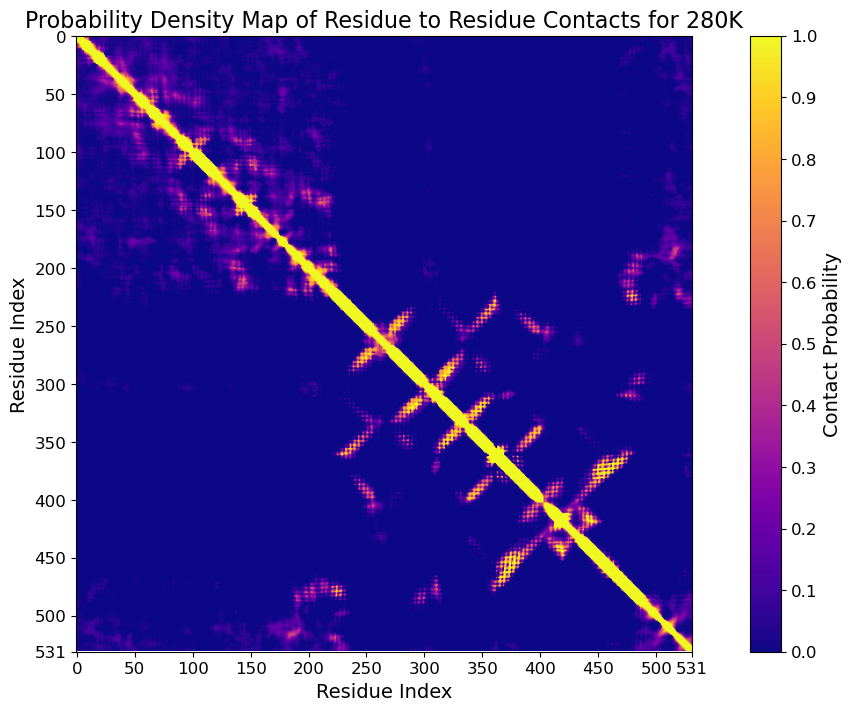

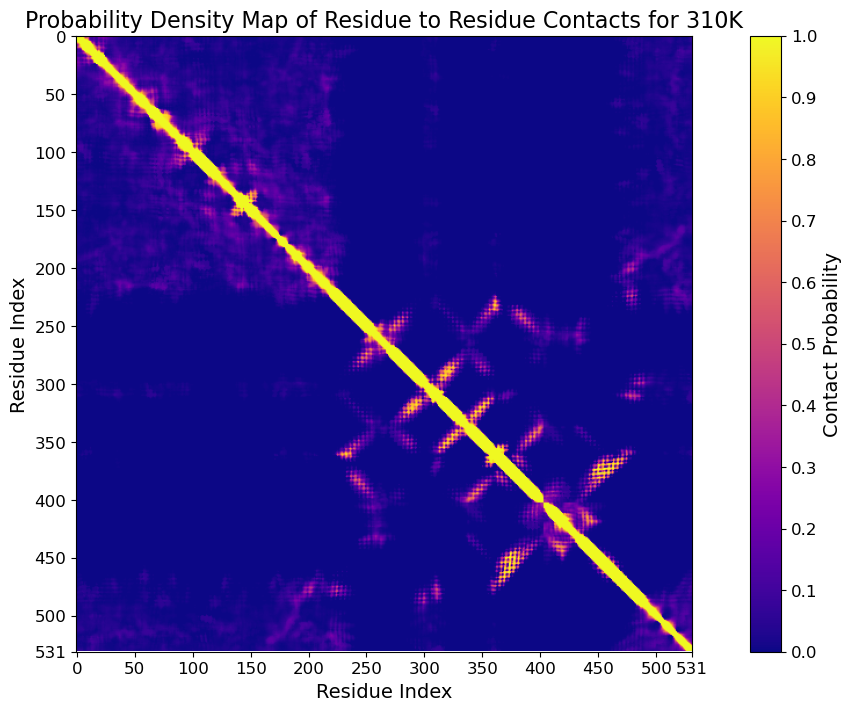

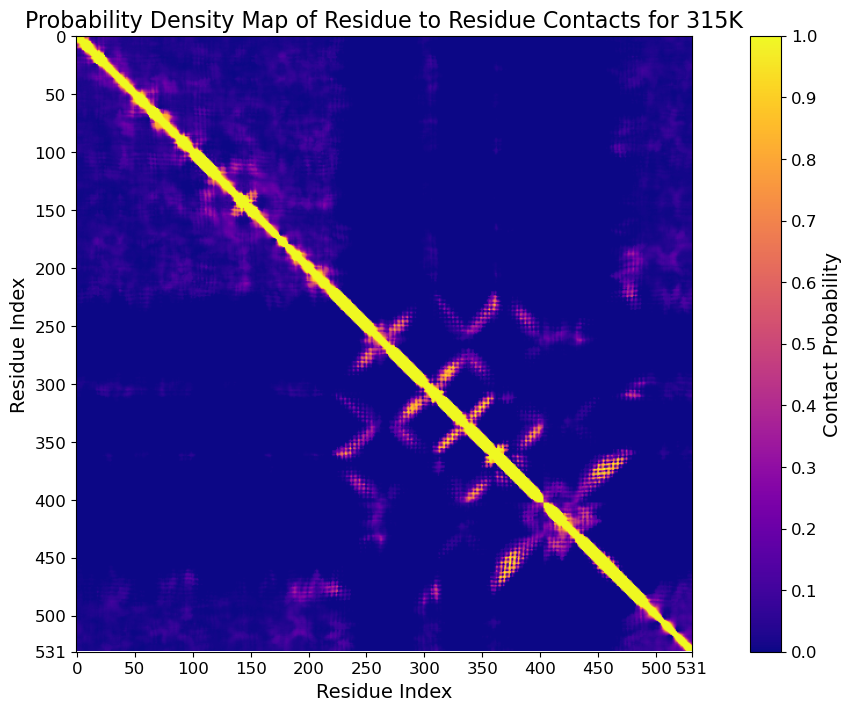

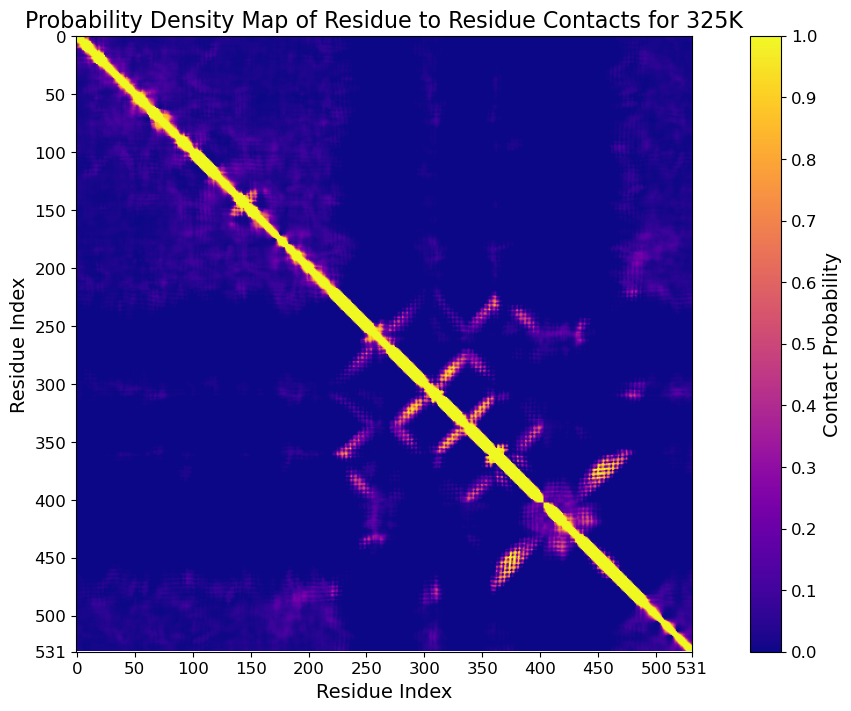

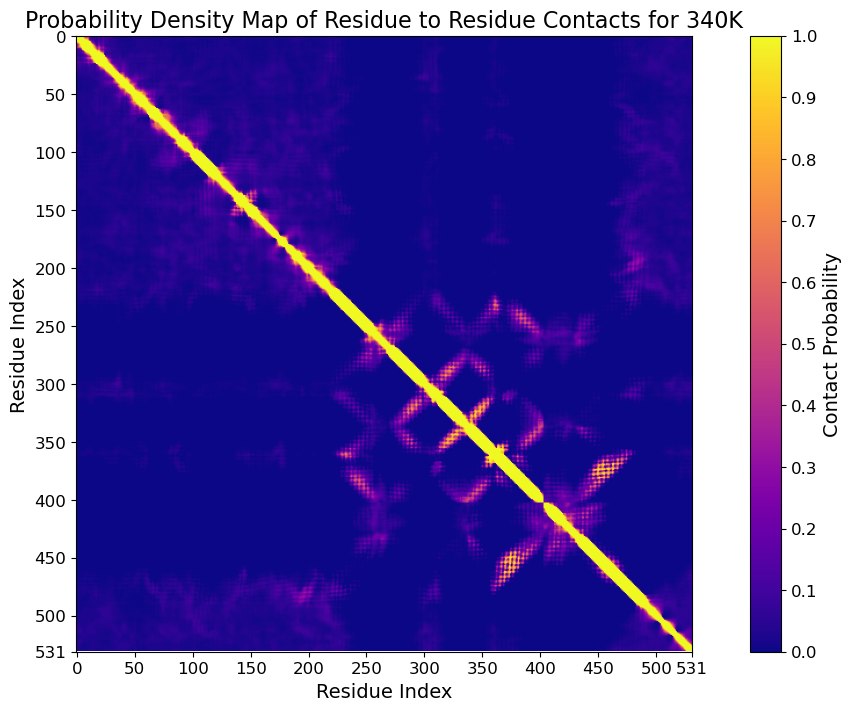

In [7]:
NumProtomer = 4
ProteinContactNetwork = ProteinNetwork.ContactFrequency

Universes280K = [0,1,2,3]
Universes310K = [4,5,6,7]
Universes315K = [8,9,10,11]
Universes325K = [12,13,14,15]
Universes340K = [16,17,18,19]

Title280K = "Probability Density Map of Residue to Residue Contacts for 280K"
Title310K = "Probability Density Map of Residue to Residue Contacts for 310K"
Title315K = "Probability Density Map of Residue to Residue Contacts for 315K"
Title325K = "Probability Density Map of Residue to Residue Contacts for 325K"
Title340K = "Probability Density Map of Residue to Residue Contacts for 340K"

ProbabilityDensity280K = ContactFrequencyNormalization(ProteinContactNetwork,Universes280K,NumProtomer)
ProteinContactFrequencyPlotting(ProbabilityDensity280K,Title280K)

ProbabilityDensity310K = ContactFrequencyNormalization(ProteinContactNetwork,Universes310K,NumProtomer)
ProteinContactFrequencyPlotting(ProbabilityDensity310K,Title310K)

ProbabilityDensity315K = ContactFrequencyNormalization(ProteinContactNetwork,Universes315K,NumProtomer)
ProteinContactFrequencyPlotting(ProbabilityDensity315K,Title315K)

ProbabilityDensity325K = ContactFrequencyNormalization(ProteinContactNetwork,Universes325K,NumProtomer)
ProteinContactFrequencyPlotting(ProbabilityDensity325K,Title325K)

ProbabilityDensity340K = ContactFrequencyNormalization(ProteinContactNetwork,Universes340K,NumProtomer)
ProteinContactFrequencyPlotting(ProbabilityDensity340K,Title340K)

Protein Contact Networkx Map Plotting for Temperature

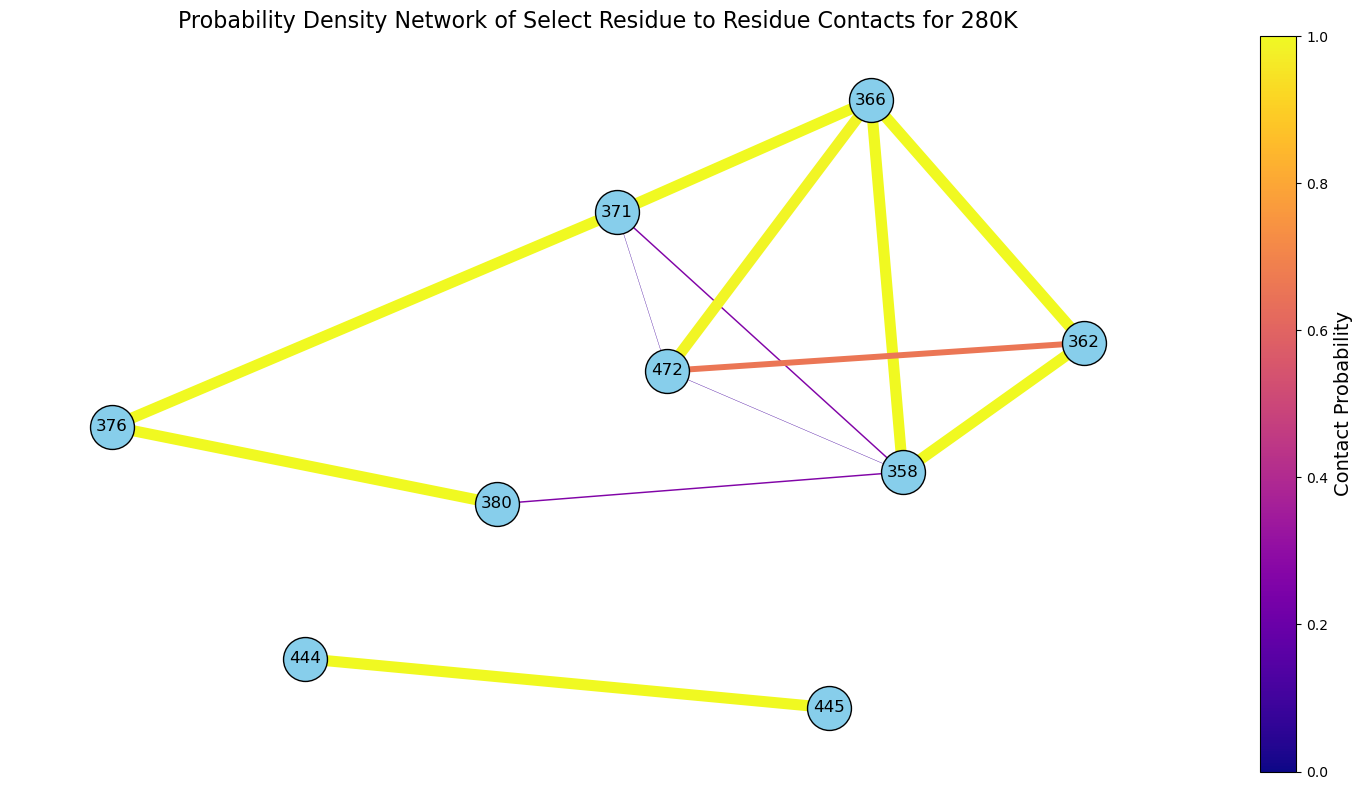

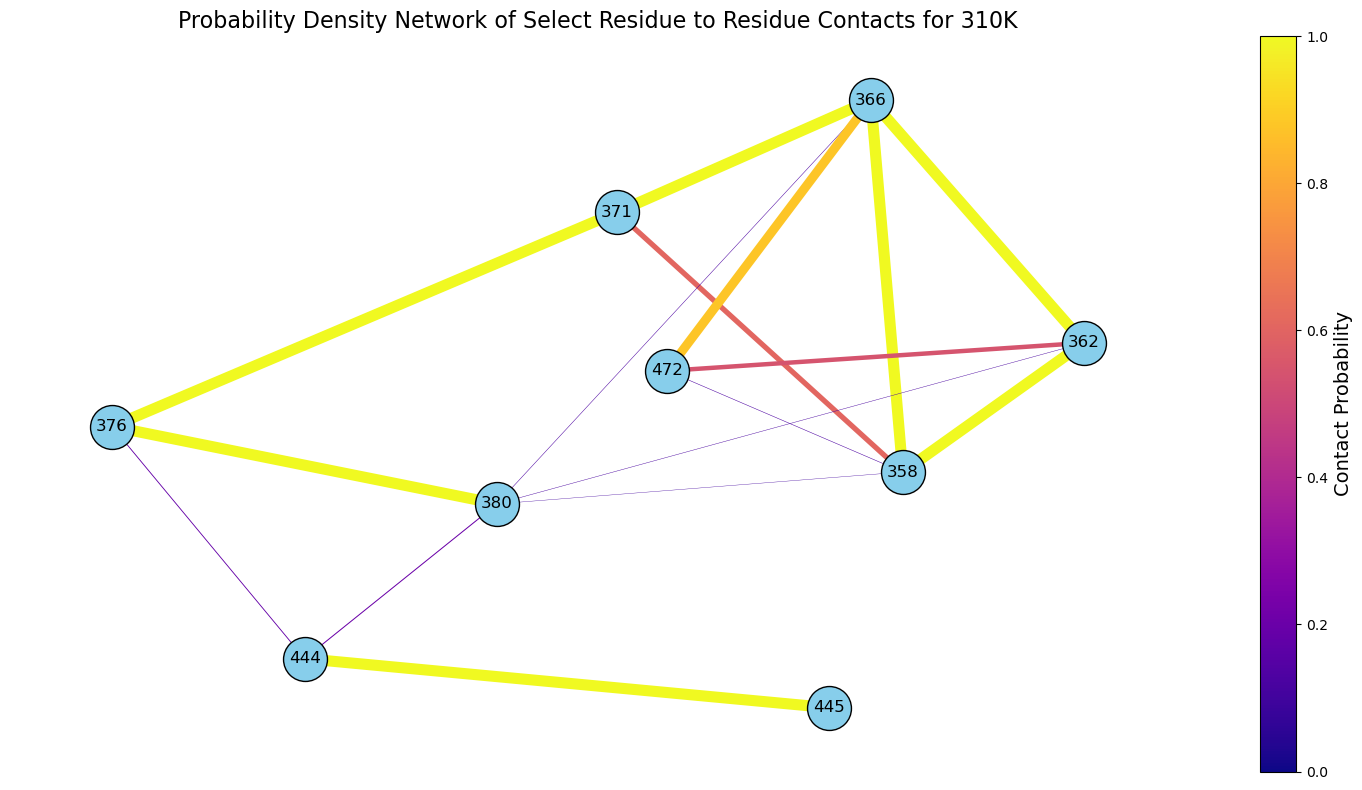

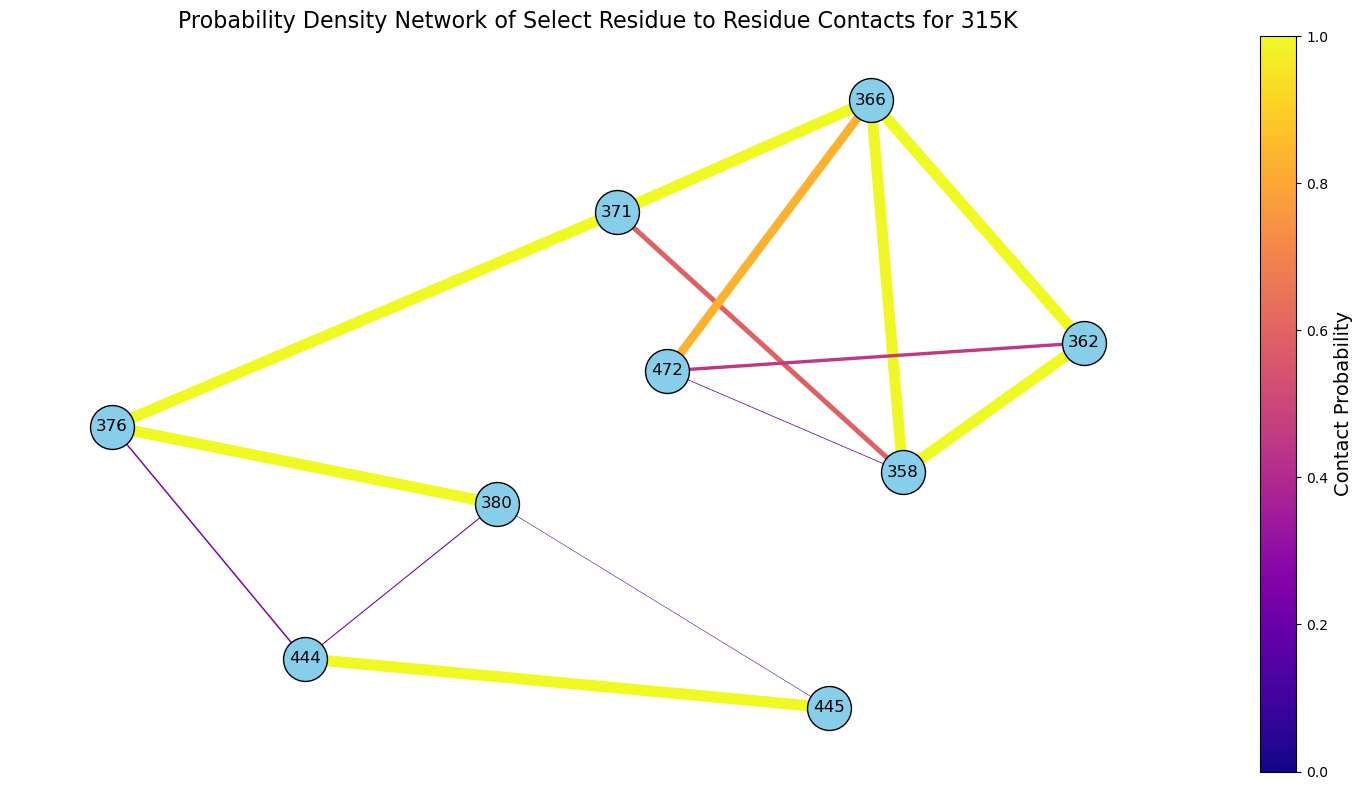

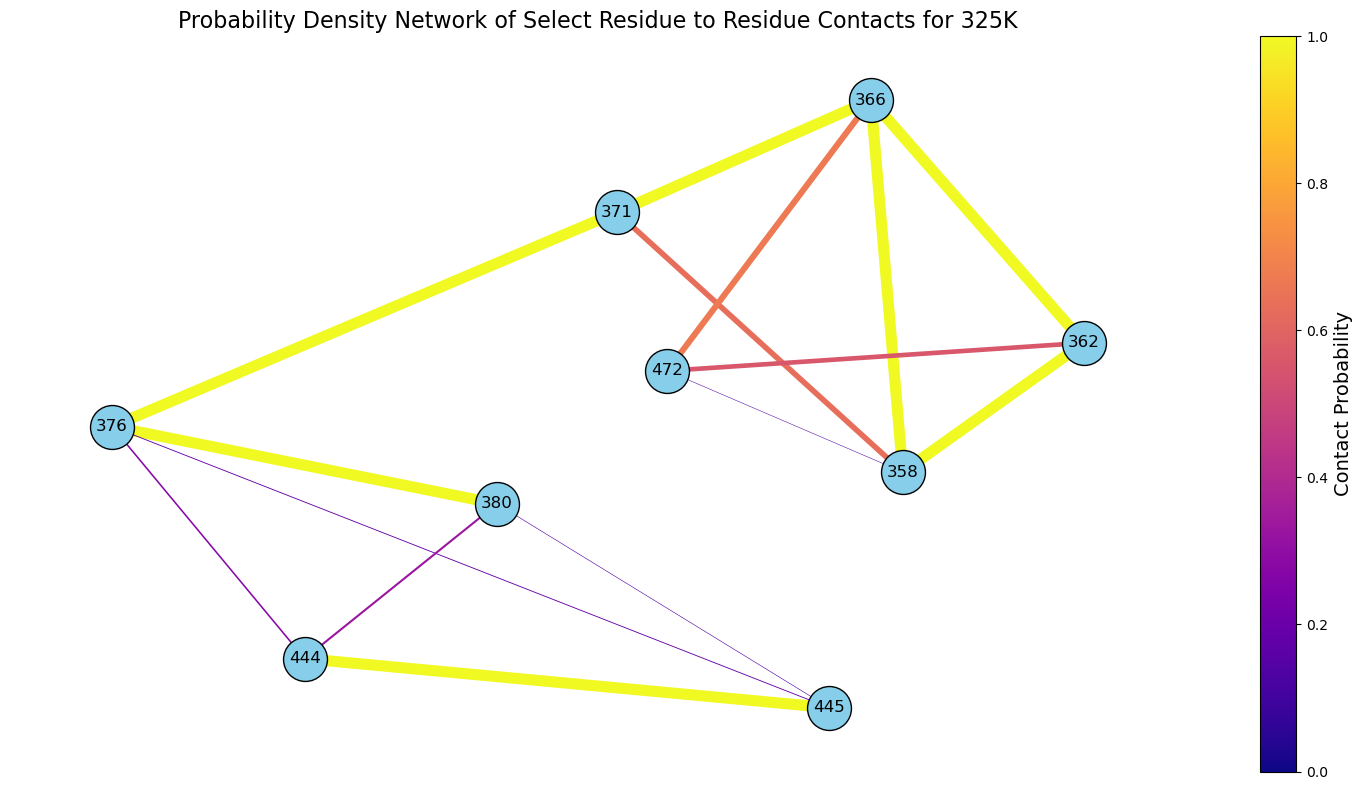

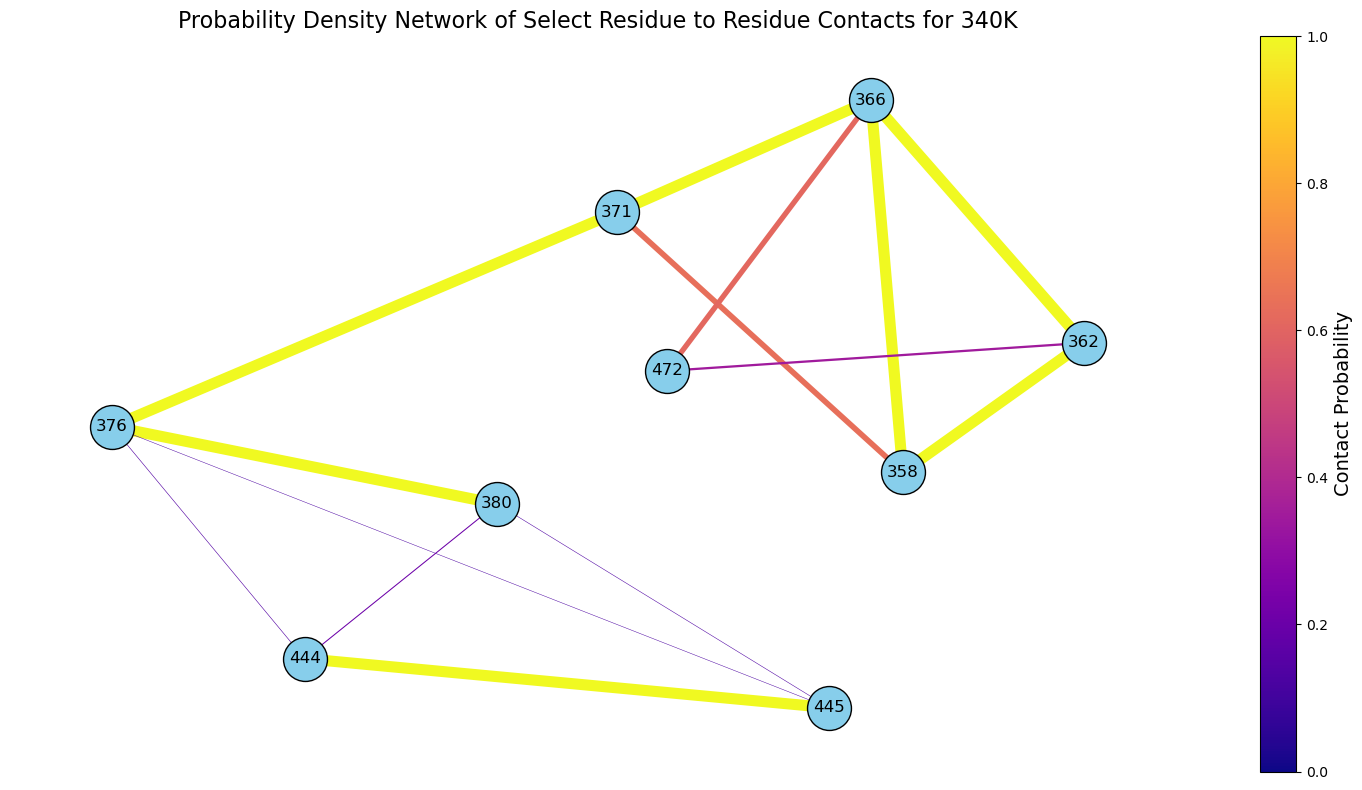

In [38]:
NumProtomer = 4
ProteinContactNetwork = ProteinNetwork.ContactFrequency

Universes280K = [0,1,2,3]
Universes310K = [4,5,6,7]
Universes315K = [8,9,10,11]
Universes325K = [12,13,14,15]
Universes340K = [16,17,18,19]

Title280K = "Probability Density Network of Select Residue to Residue Contacts for 280K"
Title310K = "Probability Density Network of Select Residue to Residue Contacts for 310K"
Title315K = "Probability Density Network of Select Residue to Residue Contacts for 315K"
Title325K = "Probability Density Network of Select Residue to Residue Contacts for 325K"
Title340K = "Probability Density Network of Select Residue to Residue Contacts for 340K"

ProbabilityDensity280K = ContactFrequencyNormalization(ProteinContactNetwork,Universes280K,NumProtomer)
ProbabilityDensity310K = ContactFrequencyNormalization(ProteinContactNetwork,Universes310K,NumProtomer)
ProbabilityDensity315K = ContactFrequencyNormalization(ProteinContactNetwork,Universes315K,NumProtomer)
ProbabilityDensity325K = ContactFrequencyNormalization(ProteinContactNetwork,Universes325K,NumProtomer)
ProbabilityDensity340K = ContactFrequencyNormalization(ProteinContactNetwork,Universes340K,NumProtomer)

ProbabilityDensities = np.array([ProbabilityDensity280K,ProbabilityDensity310K,ProbabilityDensity315K,
                                 ProbabilityDensity325K,ProbabilityDensity340K])
Indices = [357,361,365,370,375,379,443,444,471]
Titles = [Title280K,Title310K,Title315K,Title325K,Title340K]
NetworkxInteractionPlottingMultiple(ProbabilityDensities,Indices,Titles)